In [5]:
import os
print(os.getcwd())

/data/users/eibro


In [6]:
import pickle

#path to the pkl file
path='/data/users/eibro/Dataset_Edin.pkl'

#load data
with open(path, 'rb') as file:
    data=pickle.load(file)


In [7]:
#looking for the keys to understand more about the MRI
print(data.keys())


dict_keys(['FA', 'MD', 'Labels', 'SUBJ_ID', 'INFO'])


In [8]:
#trying to understand the dimension of the FA and MD
print(f"Shape: {data['FA'].shape}")
print(f"Shape: {data['MD'].shape}")

#first 5 subjets
print(f"Primi soggetti: {data['SUBJ_ID'][:5]}")

Shape: (377, 91, 109, 91)
Shape: (377, 91, 109, 91)
Primi soggetti: ['002_S_4213' '002_S_4229' '002_S_4654' '002_S_4799' '002_S_6007']


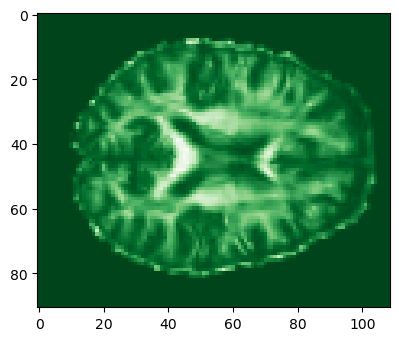

In [10]:
import matplotlib.pyplot as plt
import numpy as np

#selecting the first subject
soggetto_idx=0
mappa_fa=data['FA'][soggetto_idx]

fetta_centrale=mappa_fa.shape[2]//2

plt.figure(figsize=(10,5))

#showing FA
plt.subplot(1, 2, 1)
plt.imshow(mappa_fa[:,:,fetta_centrale], cmap='Greens_r')


In [11]:
data['Labels']

array([0, 0, 2, 1, 2, 0, 2, 0, 2, 0, 1, 0, 2, 1, 0, 0, 1, 1, 0, 0, 2, 2,
       1, 2, 2, 0, 0, 2, 2, 0, 0, 0, 2, 0, 0, 0, 0, 1, 2, 1, 1, 0, 2, 2,
       0, 2, 0, 2, 0, 2, 0, 1, 0, 0, 0, 2, 1, 2, 2, 2, 0, 1, 2, 0, 0, 1,
       2, 0, 0, 0, 2, 0, 0, 1, 0, 2, 2, 2, 0, 1, 2, 2, 0, 2, 0, 0, 2, 2,
       0, 2, 0, 0, 2, 0, 2, 2, 0, 0, 0, 1, 2, 0, 0, 0, 1, 0, 0, 0, 2, 0,
       2, 0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 2, 0, 2, 1, 0, 0, 0, 0, 1, 0, 1,
       2, 2, 2, 1, 2, 2, 2, 0, 0, 0, 2, 2, 2, 2, 0, 2, 2, 2, 1, 0, 0, 2,
       0, 2, 0, 0, 1, 0, 2, 2, 2, 2, 1, 1, 1, 1, 0, 1, 2, 2, 2, 2, 2, 0,
       2, 0, 1, 0, 0, 0, 0, 1, 1, 0, 2, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 2, 0, 0, 2, 0, 0, 1, 1, 0, 0, 0, 2, 0, 0, 1, 2, 1, 0, 2, 0,
       0, 2, 0, 1, 0, 2, 0, 2, 0, 2, 0, 1, 2, 0, 0, 0, 2, 2, 2, 0, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 2, 2, 0, 2, 2, 0, 2, 0, 2,
       0, 0, 1, 1, 2, 0, 0, 2, 0, 2, 2, 0, 2, 1, 2, 0, 2, 0, 1, 2, 0, 2,
       0, 0, 2, 2, 0, 2, 1, 2, 0, 1, 0, 2, 2, 0, 0,

In [12]:
#FA and MD histograms for a patient
i=0

fa=data['FA'][i]
md=data['MD'][i]

#removing background
fa_voxels=fa.flatten()
fa_voxels=fa_voxels[fa_voxels>0]

md_voxels=md.flatten()
md_voxels=md_voxels[md_voxels>0]

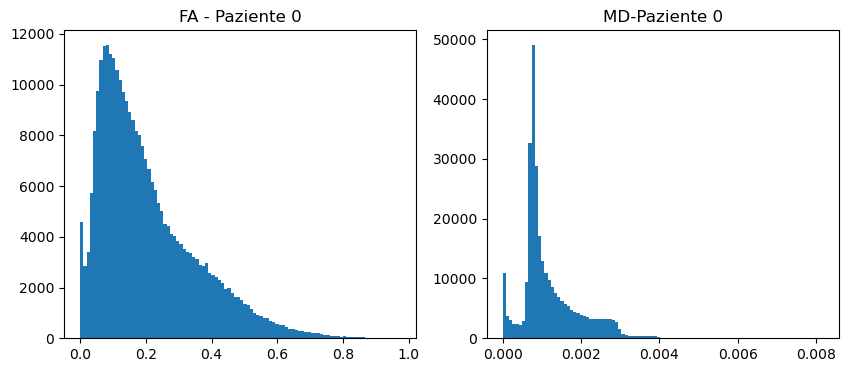

In [13]:
#histograms

plt.figure(figsize=(10,4))

#FA
plt.subplot(1,2,1)
plt.hist(fa_voxels, bins=100)
plt.title('FA - Paziente {}'.format(i))

#MD
plt.subplot(1,2,2)
plt.hist(md_voxels, bins=100)
plt.title("MD-Paziente {}".format(i))

plt.show()

#i dati sembrano essere puliti, per FA ho valori di picco
#intorno 0.2 mentre per MD ho valori molto più bassi in prossimità
#del picco


In [14]:
print("FA min/max:", fa_voxels.min(), fa_voxels.max())
print("MD min/max:", md_voxels.min(), md_voxels.max())



FA min/max: 1.8725563233569772e-07 0.9748977837653723
MD min/max: 3.26648599011011e-15 0.00817974014716948


In [15]:
import numpy as np

#costruisco una rappresentazione globale dei valori dei FA e MD per ogni classe


FA=data['FA']   #prendo i volumi 3d del soggetto i 
MD=data['MD']   #prendo i volumi 3D del soggetto i 
labels=np.array(data['Labels']).astype(int)   #prendo la classe dell'oggetto

classes=np.unique(labels)   #trova le classi presenti nel dataset

#creo due dizionari
#la chiave è data dalla classe
#il valore corrispondente è la lista di array voxel FA e MD
fa_by_class={c: [] for c in classes}
md_by_class={c: [] for c in classes}

#scorro i pazienti
#estrazione voxel per soggetto
#con flatten trasformo il voxel in un vettore 1D cosi ho una lista di numeri
#aggiungo il cervello del soggetto i alla sua classe
for i in range(len(labels)):
    c=labels[i]
    fa_by_class[c].append(FA[i].flatten())
    md_by_class[c].append(MD[i].flatten())  



for c in classes:
    fa = np.array(fa_by_class[c])
    md = np.array(md_by_class[c])
    
    # Create a mask where both conditions are met
    # Note: This only works if fa and md started with the same shape!
    common_mask = (fa > 0.01) & (md > 0) & (md<1.0)
     
    fa_by_class[c] = fa[common_mask]
    md_by_class[c] = md[common_mask]


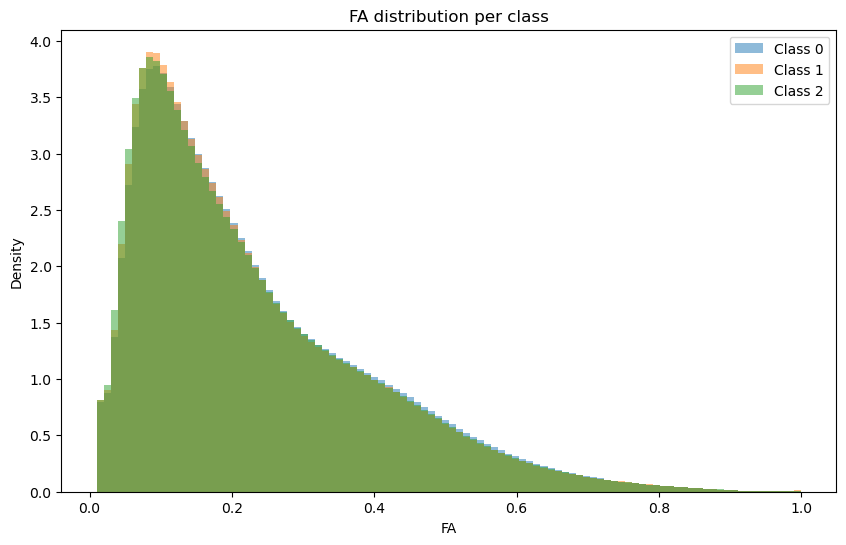

In [16]:
#mean voxels and histograms
plt.figure(figsize=(10,6))

for c in classes:
    plt.hist(
             fa_by_class[c],
             bins=100,
             alpha=0.5,
             density=True,
             label=f"Class {c}"
        )
    
plt.title("FA distribution per class")
plt.xlabel("FA")
plt.ylabel("Density")
plt.legend()
plt.show()


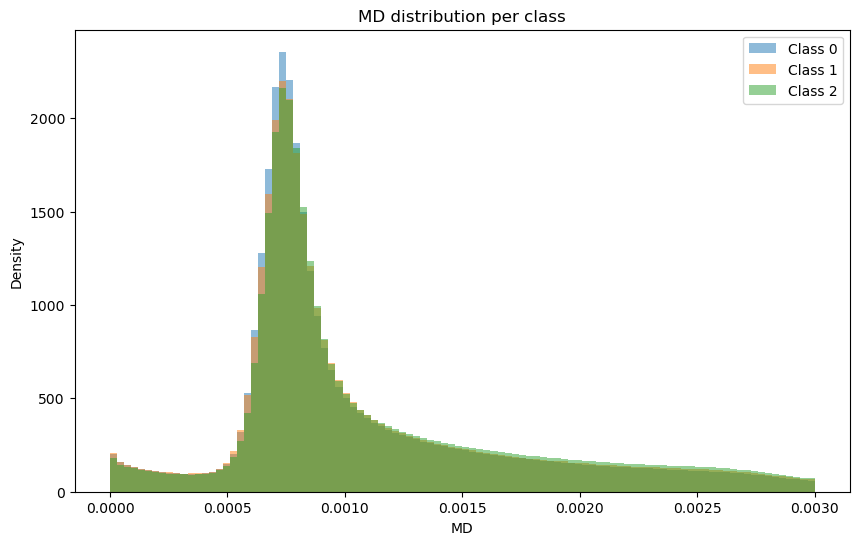

In [17]:
#mean voxels and histograms
plt.figure(figsize=(10,6))

for c in classes:

    plt.hist(
             md_by_class[c],
             bins=100,
             range=(0, 0.003),
             alpha=0.5,
             density=True,
             label=f"Class {c}"
        )
    
plt.title("MD distribution per class")
plt.xlabel("MD")
plt.ylabel("Density")
plt.legend()
plt.show()

In [18]:
print(np.max(md_by_class[0]))

0.9994533897195996


In [20]:
#quello che faccio ora è calcolare la media di voxel 
#per ogni paziente. Ottengo cosi 377 punti nel grafico, 
#divisi per le tre classi.

import numpy as np
import pandas as pd
import matplotlib as plti
import seaborn as sns

#preparazione delle liste per i risultati
stats_list=[]

#ciclo sui pazienti per calcolare le medie
for i in range(len(labels)):
    c=labels[i]

    #prendiamo i volumi del singolo paziente
    fa_voxels=FA[i].flatten()
    md_voxels=MD[i].flatten()

    #applichiamo il filtro per eliminare rumore(0) e outlier estremi
    mask=(fa_voxels>0.01) & (md_voxels>0) & (md_voxels<1.0)

    #calcolo la media dei voxels validi per il paziente
    if np.any(mask):    #verifico che ci siano voxels validi
        mean_fa=np.mean(fa_voxels[mask])
        mean_md=np.mean(md_voxels[mask])


        #salviamo i risultati in un dizionario
        stats_list.append({
            'Classe': f"Classe{c}",
            'FA_Media': mean_fa,
            'MD_Media': mean_md
        })


#trasformo tutto in un DataFrame (una tabella) per facilitare il plot
df_stats=pd.DataFrame(stats_list)

/tmp/ipykernel_94437/887637531.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='Classe', y='FA_Media', data=df_stats, palette="Set2", order=["Classe 0","Classe 1","Classe 2"])


UnboundLocalError: local variable 'boxprops' referenced before assignment

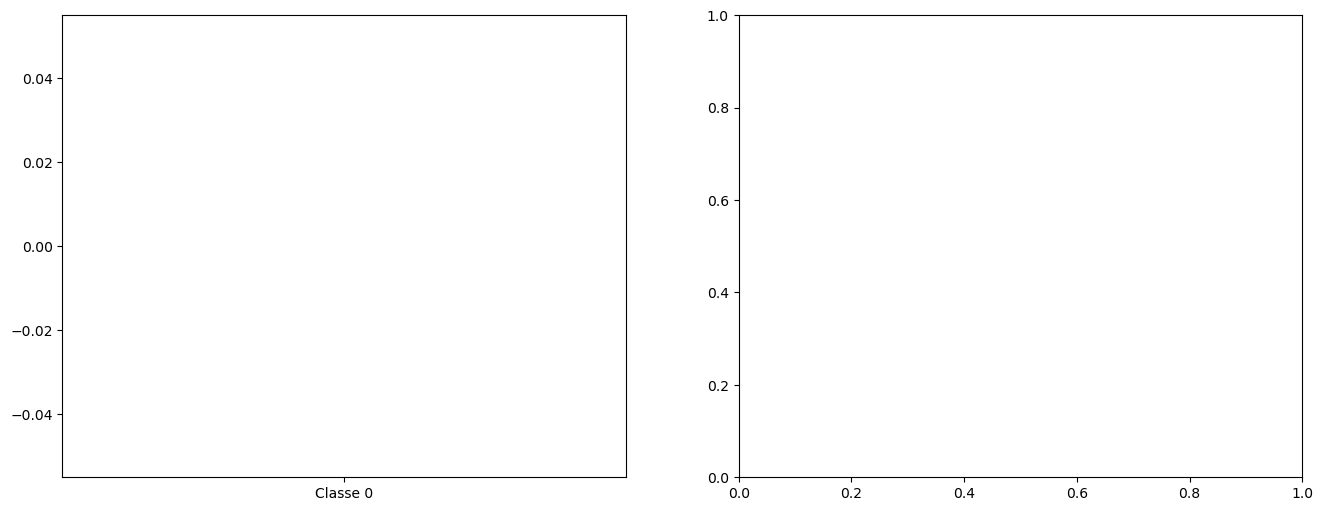

In [21]:
#creazione dei grafici (boxplot)
fig, axes=plt.subplots(1, 2, figsize=(16,6))

#boxplot per la FA
sns.boxplot(ax=axes[0], x='Classe', y='FA_Media', data=df_stats, palette="Set2", order=["Classe 0","Classe 1","Classe 2"])
axes[0].set_title('Integrità Strutturale (FA Media per Paziente)')
axes[0].set_ylabel('Fractional Anisotropy (FA)')

# Boxplot per la MD
sns.boxplot(ax=axes[1], x='Classe', y='MD_Media', data=df_stats, palette="Set2", order=["Classe 0", "Classe 1", "Classe 2"])
axes[1].set_title('Diffusività Totale (MD Media per Paziente)')
axes[1].set_ylabel('Mean Diffusivity (MD)')

plt.suptitle("Analisi Descrittiva: Differenze Medie tra Classi di Alzheimer", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()